# BNGL Sensitivity Analysis Library

This notebook provides a general-purpose class for performing sensitivity analysis on BNGL models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bionetgen
import warnings
from typing import List, Optional, Dict, Tuple
from scipy.stats import qmc
from sklearn.linear_model import LinearRegression

## BNGLSimulator Class

A class that encapsulates model simulation and sensitivity analysis functionality.

In [2]:
class BNGLSimulator:
    """
    A class for simulating BNGL models and performing sensitivity analysis.
    
    Attributes:
        model: BioNetGen model object
        sim: RoadRunner simulator object
        observables: List of observable names
        parameters: List of parameter names
    """
    
    def __init__(self, bngl_file: str):
        """
        Initialize the simulator with a BNGL model file.
        
        Args:
            bngl_file: Path to the BNGL model file
        """
        self.model = bionetgen.bngmodel(bngl_file)
        self.sim = self.model.setup_simulator()
        self.observables = [o for o in self.model.observables]
        self.parameters = [p for p in self.model.parameters if not p.startswith('_')]
        
        # Configure integrator for better tolerance
        try:
            self.sim.integrator.setValue('maximum_num_steps', 20000)
            self.sim.integrator.setValue('absolute_tolerance', 1e-12)
            self.sim.integrator.setValue('relative_tolerance', 1e-9)
        except:
            pass
    
    def simulate(self, t_end: float = 1200, n_steps: int = 200, 
                 reset: bool = True) -> np.ndarray:
        """
        Run a simulation with current parameter values.
        
        Args:
            t_end: End time for simulation
            n_steps: Number of time steps
            reset: Whether to reset the simulator before running
            
        Returns:
            Simulation results as a numpy array
        """
        if reset:
            self.sim.reset()
        
        selections = ['Time'] + self.observables
        return self.sim.simulate(0, t_end, n_steps, selections=selections)
    
    def set_parameter(self, param_name: str, value: float):
        """
        Set a parameter value.
        
        Args:
            param_name: Name of the parameter
            value: New value for the parameter
        """
        self.sim[param_name] = value
    
    def get_parameter(self, param_name: str) -> float:
        """
        Get a parameter value.
        
        Args:
            param_name: Name of the parameter
            
        Returns:
            Current value of the parameter
        """
        return self.sim[param_name]
    
    def reset_all(self):
        """Reset all parameters to their original values."""
        self.sim.resetAll()
    
    def local_sensitivity_analysis(
        self,
        observable: str,
        parameters: Optional[List[str]] = None,
        t_end: float = 600,
        n_steps: int = 200,
        perturbation: float = 1e-4
    ) -> Dict[str, np.ndarray]:
        """
        Perform local sensitivity analysis on specified parameters.
        
        Args:
            observable: Name of the observable to analyze
            parameters: List of parameter names (None = all parameters)
            t_end: End time for simulation
            n_steps: Number of time steps
            perturbation: Relative perturbation size (default 1e-4 = 0.01%)
            
        Returns:
            Dictionary mapping parameter names to sensitivity time series
        """
        if parameters is None:
            parameters = self.parameters
        
        if observable not in self.observables:
            raise ValueError(f"Observable '{observable}' not found in model")
        
        # Compute nominal trajectory
        self.sim.resetAll()
        res_nom = self.simulate(t_end, n_steps)
        O_nom = res_nom[observable][1:]  # Skip t=0
        
        # Store time points for reference
        self.last_time_points = res_nom['time'][1:]
        
        # Compute sensitivities for each parameter
        sensitivities = {}
        for param in parameters:
            if param not in self.parameters:
                print(f"Warning: Parameter '{param}' not found, skipping")
                continue
            
            orig_value = self.get_parameter(param)
            self.set_parameter(param, (1 + perturbation) * orig_value)
            self.sim.reset()
            
            res_pert = self.simulate(t_end, n_steps, reset=False)
            O_pert = res_pert[observable][1:]
            
            # Compute normalized sensitivity: (dO/O) / (dp/p)
            sensitivities[param] = ((O_pert - O_nom) / O_nom) / perturbation
            
            # Reset parameter
            self.set_parameter(param, orig_value)
        
        return sensitivities
    
    def plot_local_sensitivity(
        self,
        sensitivities: Dict[str, np.ndarray],
        observable: str,
        time_index: int = -1,
        figsize: Tuple[int, int] = (10, 6)
    ):
        """
        Plot local sensitivity results as a bar chart.
        
        Args:
            sensitivities: Dictionary from local_sensitivity_analysis
            observable: Name of the observable
            time_index: Index of time point to plot (-1 = final time)
            figsize: Figure size tuple
        """
        params = list(sensitivities.keys())
        values = [sensitivities[p][time_index] for p in params]
        
        # Color bars based on sign
        colors = ['tab:blue' if v < 0 else 'tab:red' for v in values]
        
        plt.figure(figsize=figsize)
        plt.bar(params, values, color=colors)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Normalized Sensitivity')
        
        time_val = self.last_time_points[time_index]
        plt.title(f'Local Sensitivity of {observable} at t={time_val:.1f}s')
        plt.axhline(0, ls='--', color='k', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def plot_sensitivity_trajectories(
        self,
        sensitivities: Dict[str, np.ndarray],
        observable: str,
        top_n: Optional[int] = 10,
        figsize: Tuple[int, int] = (12, 6)
    ):
        """
        Plot sensitivity trajectories over time.
        
        Args:
            sensitivities: Dictionary from local_sensitivity_analysis
            observable: Name of the observable
            top_n: Number of most sensitive parameters to plot (None = all)
            figsize: Figure size tuple
        """
        # Sort parameters by absolute sensitivity at final time
        params_sorted = sorted(
            sensitivities.keys(),
            key=lambda p: abs(sensitivities[p][-1]),
            reverse=True
        )
        
        if top_n is not None:
            params_sorted = params_sorted[:top_n]
        
        plt.figure(figsize=figsize)
        for param in params_sorted:
            plt.plot(self.last_time_points, sensitivities[param], label=param)
        
        plt.xlabel('Time (s)')
        plt.ylabel('Normalized Sensitivity')
        plt.title(f'Sensitivity Trajectories for {observable}')
        plt.axhline(0, ls='--', color='k', alpha=0.3)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    
    def global_sensitivity_analysis(
        self,
        observable: str,
        parameters: Optional[List[str]] = None,
        t_end: float = 600,
        n_steps: int = 200,
        n_samples: int = 1000,
        oom_range: float = 2.0,
        seed: int = 42
    ) -> Tuple[Dict[str, float], float, np.ndarray, np.ndarray]:
        """
        Perform global sensitivity analysis using Latin Hypercube Sampling.
        
        Args:
            observable: Name of the observable to analyze
            parameters: List of parameter names (None = all parameters)
            t_end: End time for simulation
            n_steps: Number of time steps
            n_samples: Number of LHS samples
            oom_range: Orders of magnitude to vary each parameter (±)
            seed: Random seed for reproducibility
            
        Returns:
            Tuple of (sensitivity_coeffs, r2_score, outputs, log_samples)
        """
        if parameters is None:
            parameters = self.parameters
        
        if observable not in self.observables:
            raise ValueError(f"Observable '{observable}' not found in model")
        
        n_params = len(parameters)
        
        # Define log-space bounds
        log_bounds_lower = []
        log_bounds_upper = []
        nominal_values = []
        
        for p in parameters:
            nominal = self.get_parameter(p)
            nominal_values.append(nominal)
            if nominal > 0:
                log_bounds_lower.append(np.log10(nominal) - oom_range)
                log_bounds_upper.append(np.log10(nominal) + oom_range)
            else:
                # For zero parameters, use a small range
                log_bounds_lower.append(-6)
                log_bounds_upper.append(-2)
        
        log_bounds_lower = np.array(log_bounds_lower)
        log_bounds_upper = np.array(log_bounds_upper)
        
        print(f"Sampling {n_params} parameters using Latin Hypercube")
        print(f"Parameters: {parameters}")
        
        # Generate Latin Hypercube samples
        sampler = qmc.LatinHypercube(d=n_params, seed=seed)
        unit_samples = sampler.random(n=n_samples)
        
        # Scale to log-space bounds
        log_samples = qmc.scale(unit_samples, l_bounds=log_bounds_lower, u_bounds=log_bounds_upper)
        param_samples = 10**log_samples
        
        print(f"Generated {n_samples} samples")
        print(f"Sample quality (discrepancy): {qmc.discrepancy(unit_samples):.4f}")
        
        # Run simulations
        outputs = []
        failed_indices = []
        selections = ['Time'] + self.observables
        
        print("\nRunning simulations...")
        for i, params in enumerate(param_samples):
            try:
                # Set parameter values
                for j, pname in enumerate(parameters):
                    self.set_parameter(pname, params[j])
                
                # Reset and simulate
                self.sim.reset()
                
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    res = self.sim.simulate(0, t_end, n_steps, selections=selections)
                
                output_val = res[observable][-1]
                
                if np.isnan(output_val) or np.isinf(output_val):
                    outputs.append(np.nan)
                    failed_indices.append(i)
                else:
                    outputs.append(output_val)
            
            except Exception as e:
                outputs.append(np.nan)
                failed_indices.append(i)
                if len(failed_indices) <= 5:
                    print(f"  Simulation {i} failed: {type(e).__name__}")
            
            if (i + 1) % 100 == 0:
                print(f"  Completed {i+1}/{n_samples} simulations ({len(failed_indices)} failed so far)")
        
        outputs = np.array(outputs)
        
        # Report statistics
        n_failed = len(failed_indices)
        n_success = n_samples - n_failed
        print(f"\nSimulation complete!")
        print(f"  Successful: {n_success}/{n_samples} ({100*n_success/n_samples:.1f}%)")
        print(f"  Failed: {n_failed}/{n_samples} ({100*n_failed/n_samples:.1f}%)")
        
        # Filter out failed simulations
        valid_mask = ~np.isnan(outputs)
        valid_outputs = outputs[valid_mask]
        valid_log_samples = log_samples[valid_mask]
        
        print(f"\nOutput range (valid): [{valid_outputs.min():.2e}, {valid_outputs.max():.2e}]")
        
        # Perform linear regression in log space
        X_log = valid_log_samples
        y_log = np.log10(valid_outputs + 1e-10)
        
        reg = LinearRegression()
        reg.fit(X_log, y_log)
        
        sensitivity_coeffs = dict(zip(parameters, reg.coef_))
        r2_score = reg.score(X_log, y_log)
        
        print(f"\nR² score: {r2_score:.4f}")
        print(f"\nGlobal sensitivity coefficients:")
        for pname, coeff in sensitivity_coeffs.items():
            print(f"  {pname:12s}: {coeff:+.4f}")
        
        # Reset simulator to nominal values
        self.reset_all()
        
        return sensitivity_coeffs, r2_score, outputs, log_samples
    
    def plot_global_sensitivity(
        self,
        sensitivity_coeffs: Dict[str, float],
        r2_score: float,
        observable: str,
        outputs: np.ndarray,
        log_samples: np.ndarray,
        t_end: float,
        figsize: Tuple[int, int] = (14, 5)
    ):
        """
        Plot global sensitivity results.
        
        Args:
            sensitivity_coeffs: Dictionary of sensitivity coefficients
            r2_score: R² score from regression
            observable: Name of the observable
            outputs: Array of simulation outputs
            log_samples: Array of log-space parameter samples
            t_end: End time of simulations
            figsize: Figure size tuple
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Left plot: Sensitivity coefficients
        params = list(sensitivity_coeffs.keys())
        coeffs = list(sensitivity_coeffs.values())
        colors = ['tab:blue' if c < 0 else 'tab:red' for c in coeffs]
        
        ax1.bar(params, coeffs, color=colors)
        ax1.set_xticklabels(params, rotation=45, ha='right')
        ax1.set_ylabel('Sensitivity Coefficient')
        ax1.set_title(f'Global Sensitivity of {observable} at t={t_end}s')
        ax1.axhline(0, ls='--', color='k', alpha=0.3)
        
        # Right plot: Predicted vs Actual
        valid_mask = ~np.isnan(outputs)
        valid_outputs = outputs[valid_mask]
        valid_log_samples = log_samples[valid_mask]
        
        X_log = valid_log_samples
        y_log = np.log10(valid_outputs + 1e-10)
        
        reg = LinearRegression()
        reg.fit(X_log, y_log)
        y_pred = reg.predict(X_log)
        
        ax2.scatter(y_log, y_pred, alpha=0.5, s=30)
        min_val = min(y_log.min(), y_pred.min())
        max_val = max(y_log.max(), y_pred.max())
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
        ax2.set_xlabel(f'Actual log₁₀({observable})')
        ax2.set_ylabel(f'Predicted log₁₀({observable})')
        ax2.set_title(f'Prediction Accuracy (R²={r2_score:.3f})')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

## Example Usage: FcεRI Model

In [3]:
# Create simulator instance
simulator = BNGLSimulator("fceri_starter.bngl")

print(f"Model loaded: {len(simulator.parameters)} parameters, {len(simulator.observables)} observables")
print(f"\nParameters: {simulator.parameters}")
print(f"\nObservables: {simulator.observables}")

Model loaded: 11 parameters, 6 observables

Parameters: ['Lig_tot', 'Rec_tot', 'Lyn_tot', 'kp1', 'km1', 'kp2', 'km2', 'kpL', 'kmL', 'pLb', 'dm']

Observables: ['RecDimer1', 'RecDimer2', 'LynFree', 'LynBoundU', 'BetaP1', 'BetaP2']


### Basic Simulation

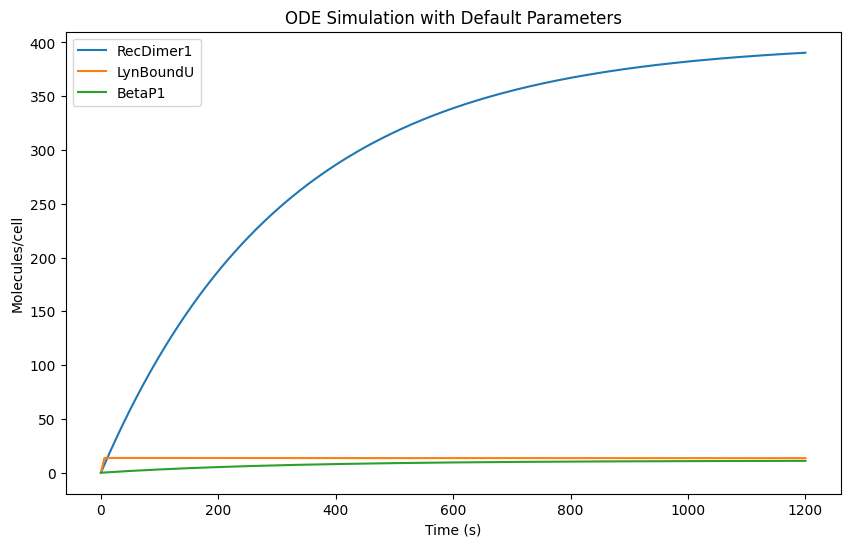

In [4]:
# Run a basic simulation
result = simulator.simulate(t_end=1200, n_steps=200)

# Plot selected observables
observables_to_plot = ['RecDimer1', 'LynBoundU', 'BetaP1']

plt.figure(figsize=(10, 6))
for obs in observables_to_plot:
    if obs in simulator.observables:
        plt.plot(result['time'], result[obs], label=obs)

plt.xlabel('Time (s)')
plt.ylabel('Molecules/cell')
plt.title('ODE Simulation with Default Parameters')
plt.legend()
plt.show()

### Local Sensitivity Analysis

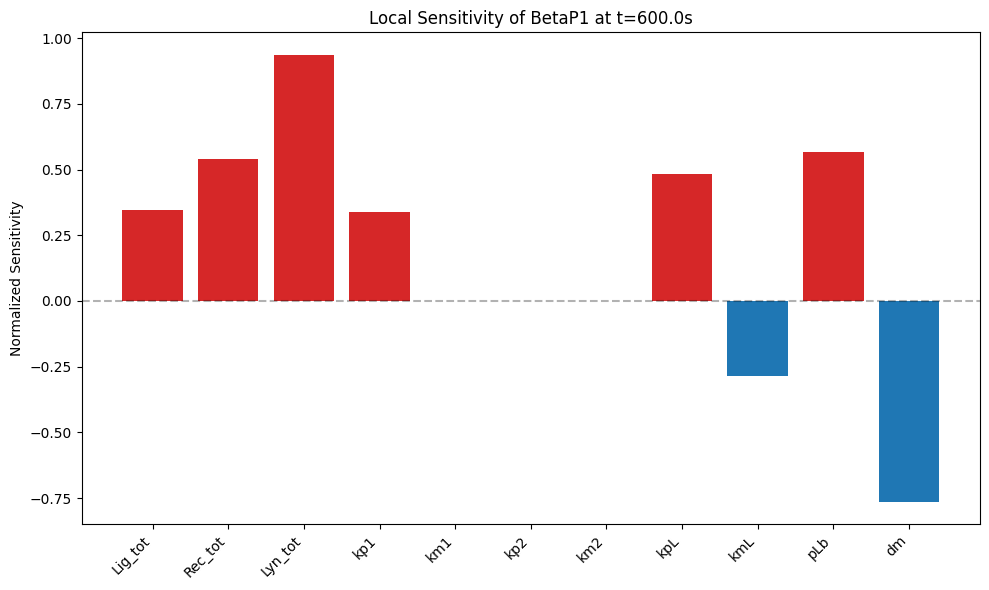

In [5]:
# Perform local sensitivity analysis
sensitivities = simulator.local_sensitivity_analysis(
    observable='BetaP1',
    t_end=600,
    n_steps=200
)

# Plot sensitivity bar chart at final time
simulator.plot_local_sensitivity(
    sensitivities=sensitivities,
    observable='BetaP1',
    time_index=-1
)

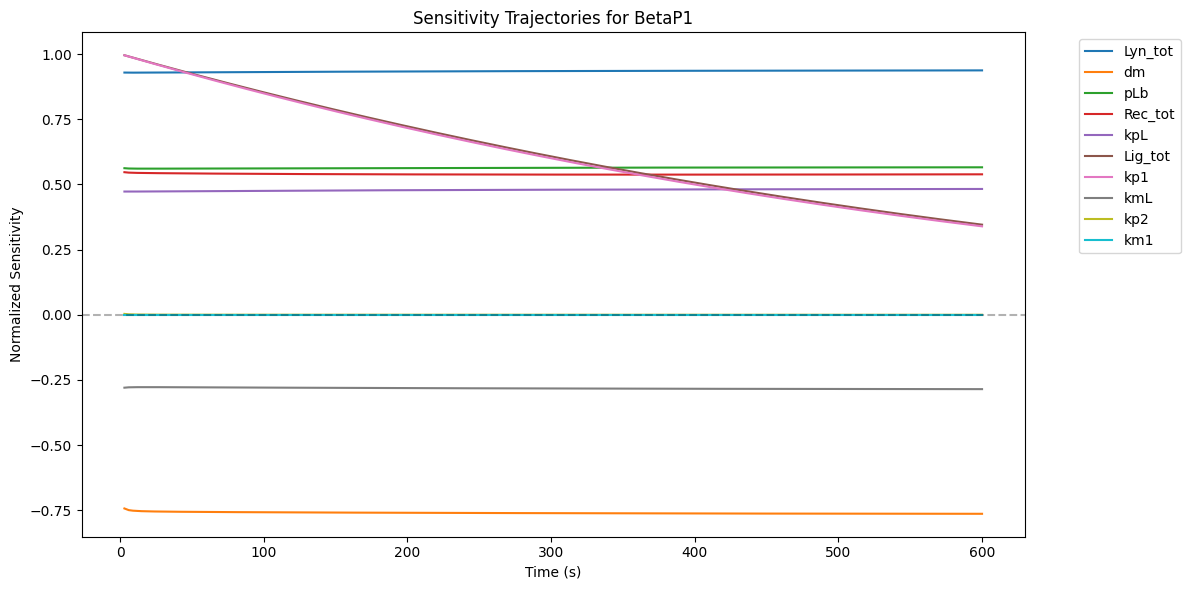

In [6]:
# Plot sensitivity trajectories over time
simulator.plot_sensitivity_trajectories(
    sensitivities=sensitivities,
    observable='BetaP1',
    top_n=10
)

### Global Sensitivity Analysis

In [7]:
# Perform global sensitivity analysis
coeffs, r2, outputs, log_samples = simulator.global_sensitivity_analysis(
    observable='BetaP1',
    t_end=600,
    n_steps=200,
    n_samples=1000,
    oom_range=2.0,
    seed=42
)

Sampling 11 parameters using Latin Hypercube
Parameters: ['Lig_tot', 'Rec_tot', 'Lyn_tot', 'kp1', 'km1', 'kp2', 'km2', 'kpL', 'kmL', 'pLb', 'dm']
Generated 1000 samples
Sample quality (discrepancy): 0.0050

Running simulations...
  Completed 100/1000 simulations (0 failed so far)
  Completed 200/1000 simulations (0 failed so far)
  Completed 300/1000 simulations (0 failed so far)
  Completed 400/1000 simulations (0 failed so far)
  Completed 500/1000 simulations (0 failed so far)
  Completed 600/1000 simulations (0 failed so far)
  Completed 700/1000 simulations (0 failed so far)
  Completed 800/1000 simulations (0 failed so far)
  Completed 900/1000 simulations (0 failed so far)
  Completed 1000/1000 simulations (0 failed so far)

Simulation complete!
  Successful: 1000/1000 (100.0%)
  Failed: 0/1000 (0.0%)

Output range (valid): [2.80e-08, 5.89e+03]

R² score: 0.8027

Global sensitivity coefficients:
  Lig_tot     : +0.5001
  Rec_tot     : +0.6472
  Lyn_tot     : +0.7138
  kp1       

/var/folders/tg/bhsjlfgx1wq0l_x5sqgjgjz80000gn/T/ipykernel_14926/4135814347.py:373: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(params, rotation=45, ha='right')


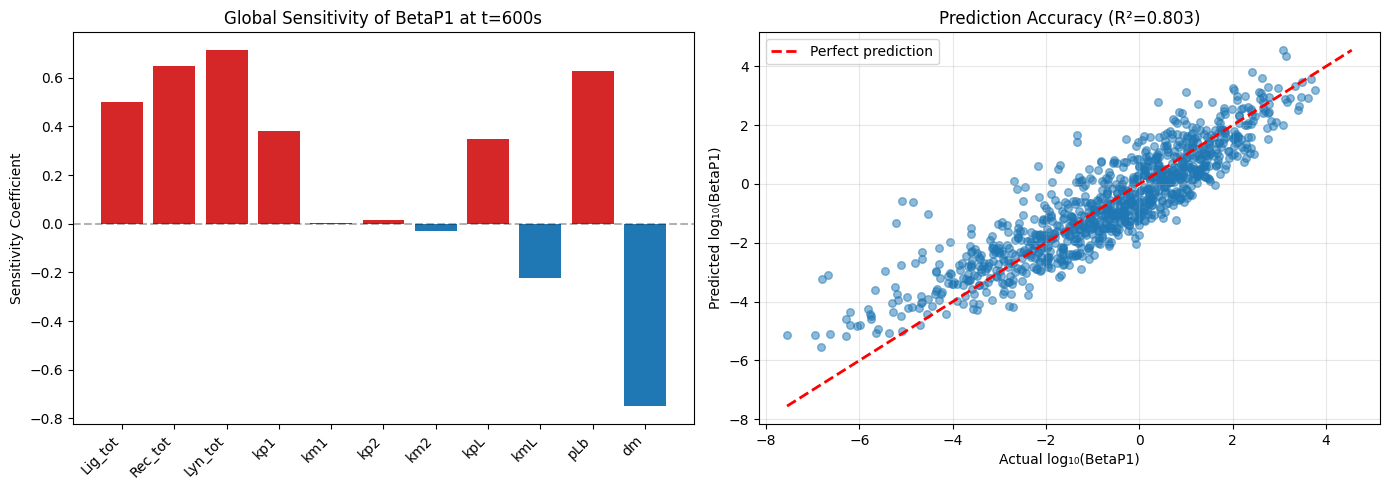

In [8]:
# Plot global sensitivity results
simulator.plot_global_sensitivity(
    sensitivity_coeffs=coeffs,
    r2_score=r2,
    observable='BetaP1',
    outputs=outputs,
    log_samples=log_samples,
    t_end=600
)

### Analyze Multiple Observables


Analyzing RecDimer1


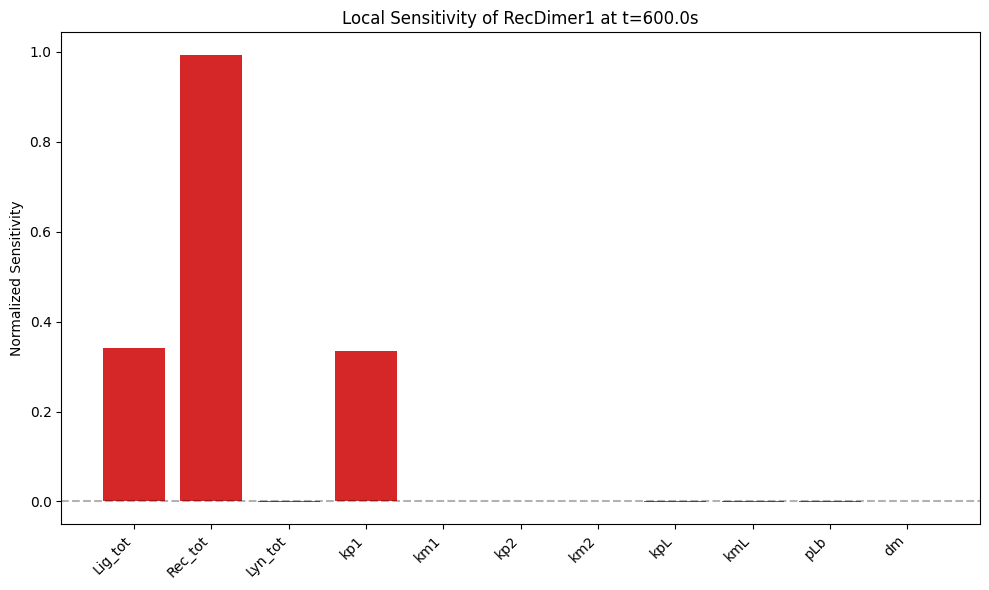


Analyzing LynBoundU


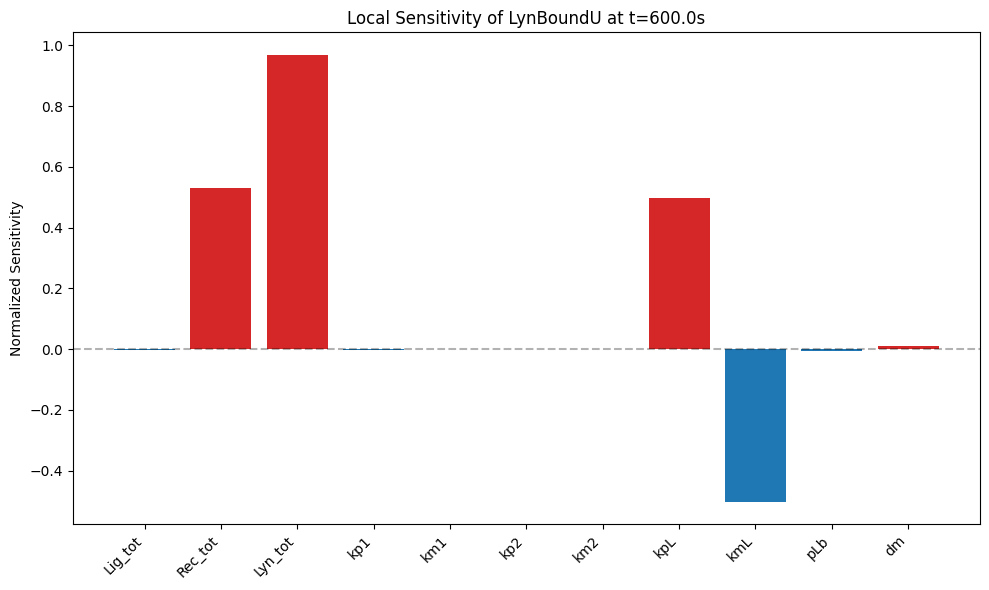


Analyzing BetaP1


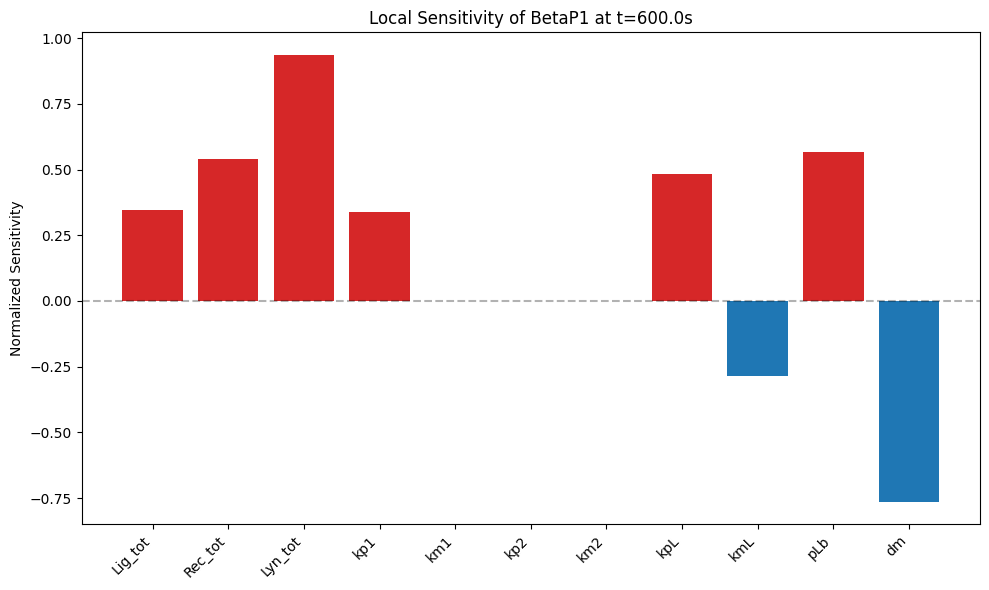

In [9]:
# Analyze sensitivity for multiple observables
observables_to_analyze = ['RecDimer1', 'LynBoundU', 'BetaP1']

for obs in observables_to_analyze:
    if obs in simulator.observables:
        print(f"\n{'='*60}")
        print(f"Analyzing {obs}")
        print('='*60)
        
        sens = simulator.local_sensitivity_analysis(
            observable=obs,
            t_end=600,
            n_steps=200
        )
        
        simulator.plot_local_sensitivity(
            sensitivities=sens,
            observable=obs,
            time_index=-1
        )

### Subset Parameter Analysis

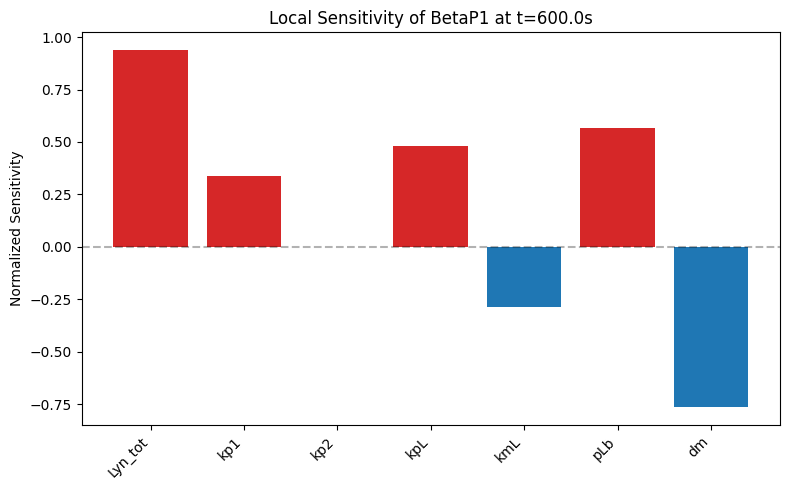

In [10]:
# Analyze only a subset of parameters
params_of_interest = ['Lyn_tot', 'kp1', 'kp2', 'kpL', 'kmL', 'pLb', 'dm']

sens_subset = simulator.local_sensitivity_analysis(
    observable='BetaP1',
    parameters=params_of_interest,
    t_end=600,
    n_steps=200
)

simulator.plot_local_sensitivity(
    sensitivities=sens_subset,
    observable='BetaP1',
    time_index=-1,
    figsize=(8, 5)
)